In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

native_df = pd.read_csv('output_files/native/native.csv')
decoys_df = pd.read_csv('output_files/decoys/decoys.csv')
all_native_df = pd.read_csv('output_files/native/all_native.csv')

def add_ring_mean_columns(df, radius_col='radius', n_rings=10):
    for ring_id in range(1, n_rings + 1):
        # Valore medio del raggio dell'anello in Angstrom
        df[f'ring{ring_id}_mean_A'] = df[radius_col] * (ring_id - 0.5) / 10
    return df

native_df = add_ring_mean_columns(native_df)
decoys_df = add_ring_mean_columns(decoys_df)
all_native_df = add_ring_mean_columns(all_native_df)

native_labeled = native_df.copy()
native_labeled['dataset_label'] = 'native'

decoys_labeled = decoys_df.copy()
decoys_labeled['complex_name'] = decoys_labeled['complex_name'].astype(str).str.split('-').str[0].str[:4]
decoys_labeled['dataset_label'] = 'decoy'

tot_df = pd.concat([native_labeled, decoys_labeled], ignore_index=True)

rings = [f'ring{n}_mean_A' for n in range(1, 11)]
zernike = [f'zernike_ring{n}_mean' for n in range(1, 11)]
zernike_sigma = [f'zernike_ring{n}_uncertainty' for n in range(1, 11)]
physical = [f'physical_ring{n}_mean' for n in range(1, 11)]
physical_sigma = [f'physical_ring{n}_uncertainty' for n in range(1, 11)]
roughness = [f'roughness_ring{n}' for n in range(1, 11)]

print('native_df:', native_df.shape)
print('decoys_df:', decoys_df.shape)
print('all_native_df:', all_native_df.shape)
print('tot_df:', tot_df.shape)

native_df: (3134, 73)
decoys_df: (3134, 73)
all_native_df: (3731, 73)
tot_df: (6268, 74)


In [2]:
import matplotlib.patches as mpatches


def build_rdf_long_df(df, metric_cols, dataset_label, radius_col='radius', n_rings=10, max_radius=50.0, bin_width=2.0):
    records = []
    n_bins = int(max_radius / bin_width)

    for _, row in df.iterrows():
        radius = pd.to_numeric(row.get(radius_col), errors='coerce')
        if not np.isfinite(radius) or radius <= 0:
            continue

        for ring_id in range(1, n_rings + 1):
            metric_value = pd.to_numeric(row.get(metric_cols[ring_id - 1]), errors='coerce')
            if not np.isfinite(metric_value):
                continue

            ring_radius = float(radius) * (ring_id - 0.5) / n_rings
            if not np.isfinite(ring_radius) or ring_radius < 0 or ring_radius > max_radius:
                continue

            bin_id = min(int(ring_radius // bin_width) + 1, n_bins)
            records.append({
                'dataset_label': dataset_label,
                'ring_id': ring_id,
                'rdf_value': float(metric_value),
                'ring_radius_A': ring_radius,
                'radius_bin_id': bin_id,
                'radius_bin_center_A': bin_id * bin_width - bin_width / 2.0,
            })

    return pd.DataFrame.from_records(records)


palette = {'native': '#1f77b4', 'decoy': '#d62728'}

physical_plot_df = pd.concat([
    build_rdf_long_df(native_df, physical, 'native'),
    build_rdf_long_df(decoys_df, physical, 'decoy'),
] , ignore_index=True)
zernike_plot_df = pd.concat([
    build_rdf_long_df(native_df, zernike, 'native'),
    build_rdf_long_df(decoys_df, zernike, 'decoy'),
] , ignore_index=True)
roughness_plot_df = pd.concat([
    build_rdf_long_df(native_df, roughness, 'native'),
    build_rdf_long_df(decoys_df, roughness, 'decoy'),
] , ignore_index=True)

print('physical_plot_df:', physical_plot_df.shape)
print('zernike_plot_df:', zernike_plot_df.shape)
print('roughness_plot_df:', roughness_plot_df.shape)

physical_plot_df: (62136, 6)
zernike_plot_df: (62136, 6)
roughness_plot_df: (62136, 6)


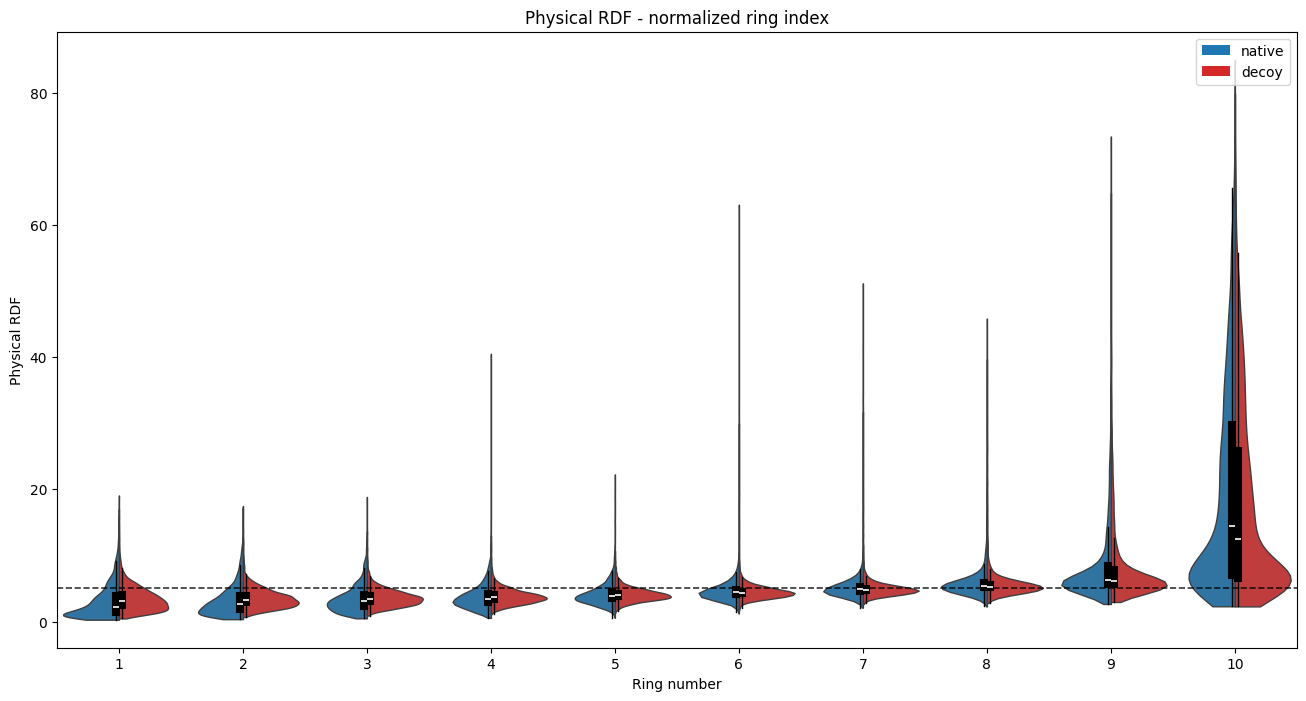

In [18]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(
    data=physical_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    split=True,
    inner=None,
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
sns.boxplot(
    data=physical_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    width=0.10,
    whis=1.5,
    showfliers=False,
    showcaps=False,
    boxprops={'facecolor': 'black', 'edgecolor': 'black', 'zorder': 3},
    whiskerprops={'color': 'black', 'linewidth': 1.0},
    capprops={'color': 'black', 'linewidth': 0.0},
    medianprops={'color': 'white', 'linewidth': 1.2, 'zorder': 5},
    ax=ax,
)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.legend(handles=[
    mpatches.Patch(facecolor=palette['native'], label='native'),
    mpatches.Patch(facecolor=palette['decoy'], label='decoy'),
], title='')
ax.axhline(5, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_title('Physical RDF - normalized ring index')
ax.set_xlabel('Ring number')
ax.set_ylabel('Physical RDF')
fig.savefig('plots/physical_rdf_normalized.pdf', bbox_inches='tight')
plt.show()

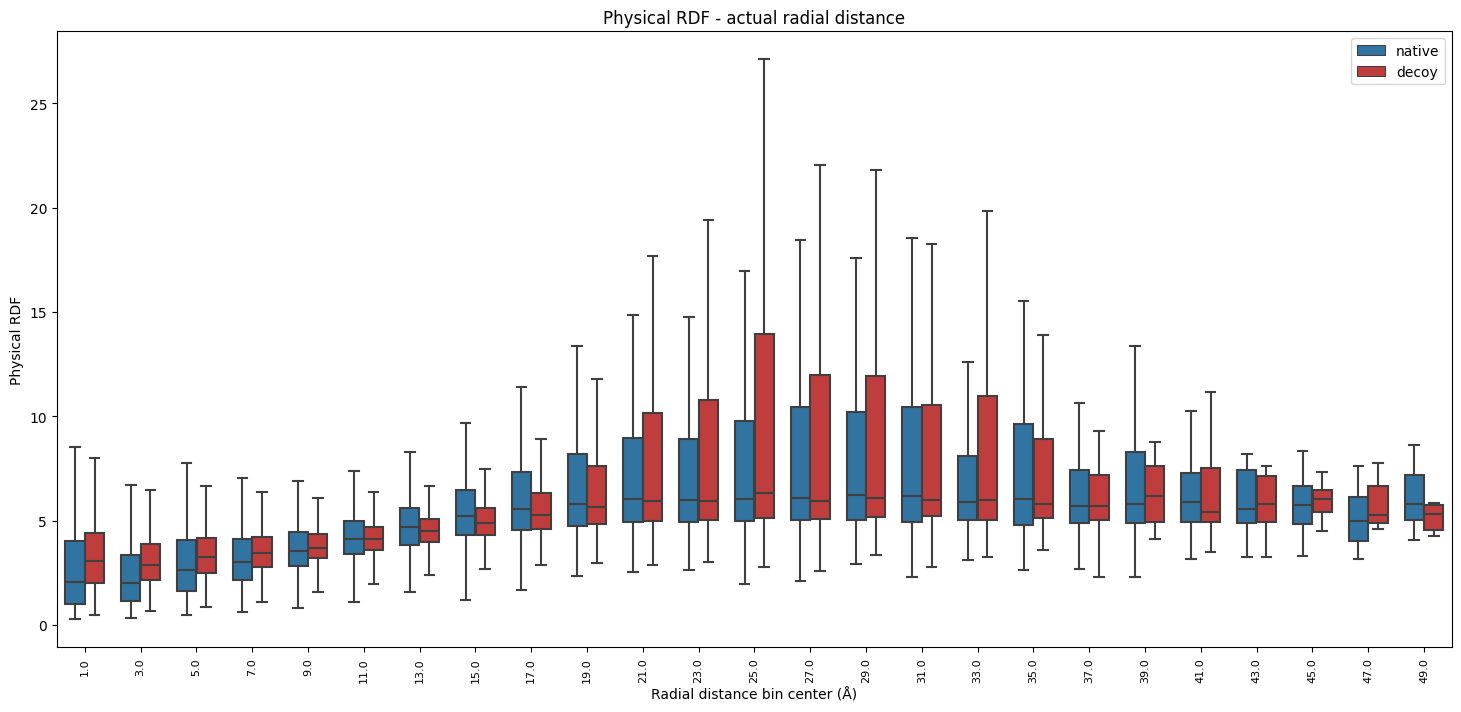

In [4]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=physical_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    showfliers=False,
    width=0.7,
    ax=ax,
)
ax.set_title('Physical RDF - actual radial distance')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Physical RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
fig.savefig('plots/physical_rdf_radial.pdf', bbox_inches='tight')
plt.show()

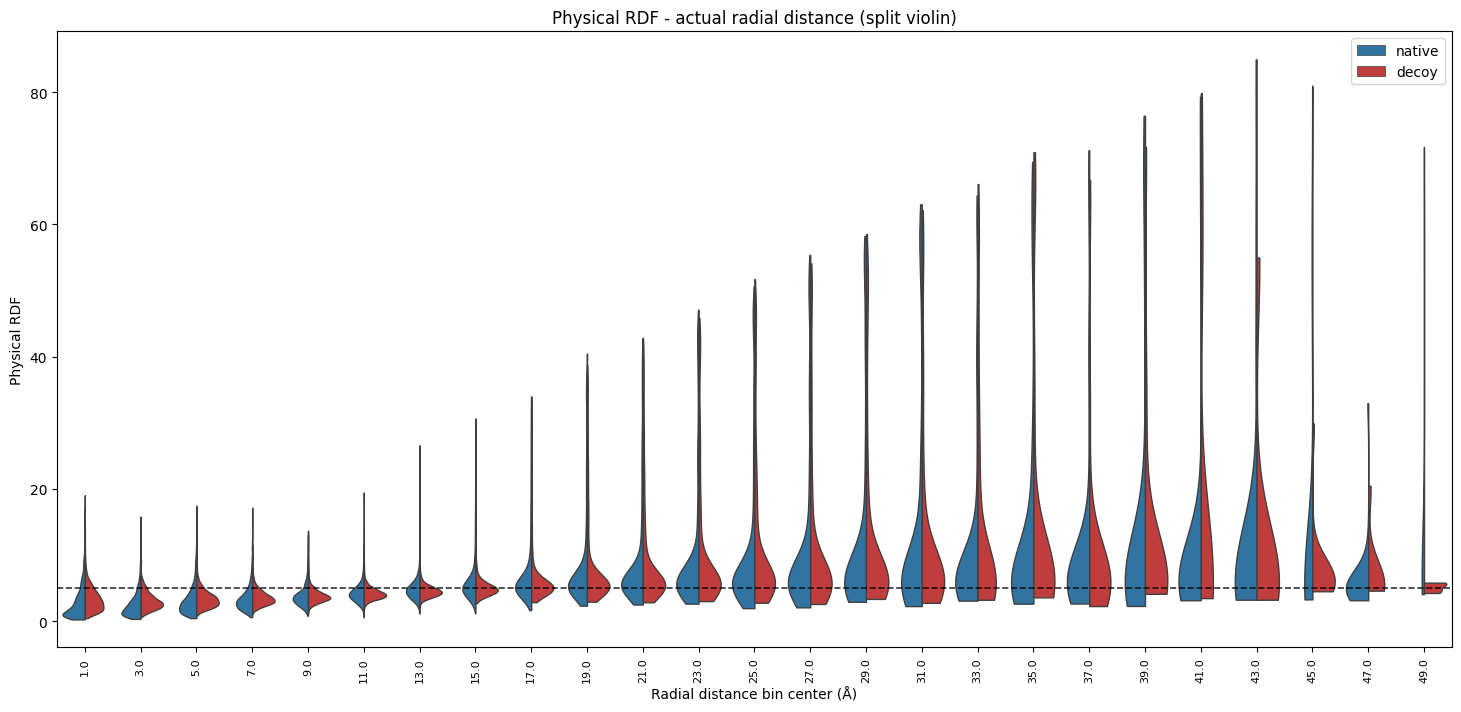

In [17]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.violinplot(
    data=physical_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    split=True,
    palette=palette,
    inner=None,
    cut=0,
    width=0.8,
    linewidth=1,
    ax=ax,
)
ax.axhline(5, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_title('Physical RDF - actual radial distance (split violin)')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Physical RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
fig.savefig('plots/physical_rdf_radial_violin.pdf', bbox_inches='tight')
plt.show()

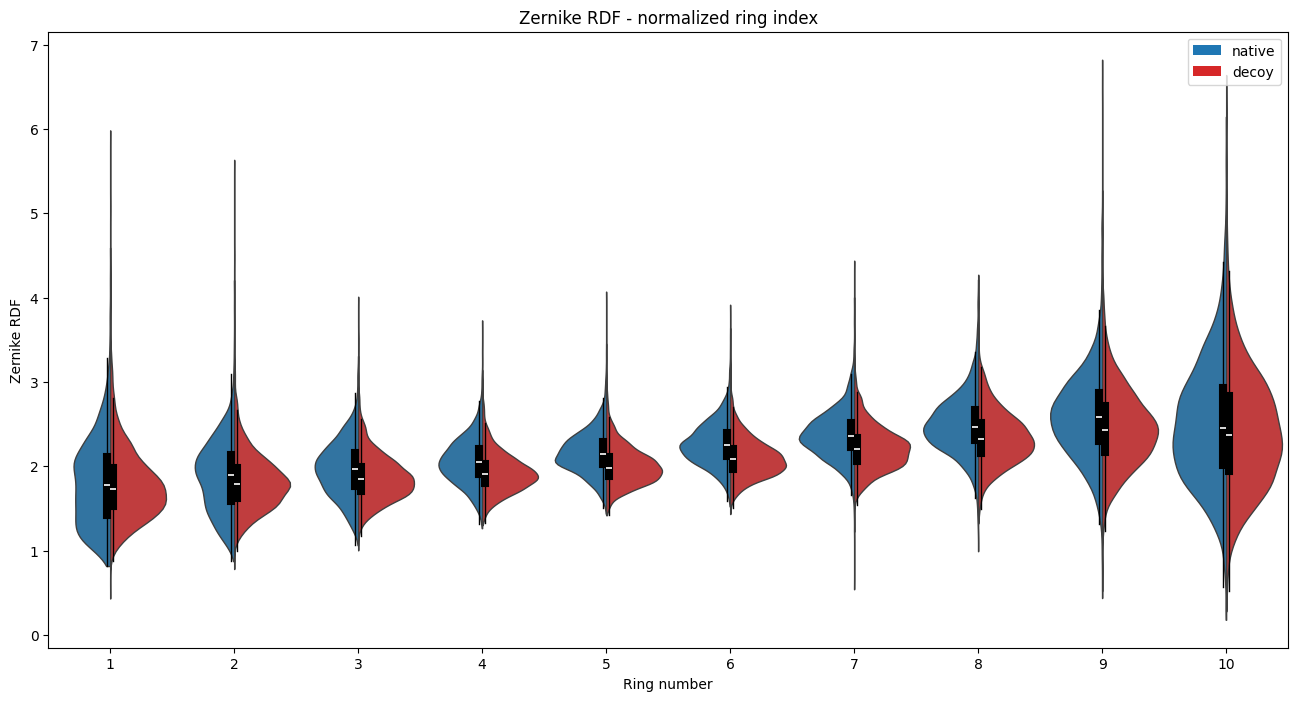

In [5]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(
    data=zernike_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    split=True,
    inner=None,
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
sns.boxplot(
    data=zernike_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    width=0.10,
    whis=1.5,
    showfliers=False,
    showcaps=False,
    boxprops={'facecolor': 'black', 'edgecolor': 'black', 'zorder': 3},
    whiskerprops={'color': 'black', 'linewidth': 1.0},
    capprops={'color': 'black', 'linewidth': 0.0},
    medianprops={'color': 'white', 'linewidth': 1.2, 'zorder': 5},
    ax=ax,
)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.legend(handles=[
    mpatches.Patch(facecolor=palette['native'], label='native'),
    mpatches.Patch(facecolor=palette['decoy'], label='decoy'),
], title='')
ax.set_title('Zernike RDF - normalized ring index')
ax.set_xlabel('Ring number')
ax.set_ylabel('Zernike RDF')
fig.savefig('plots/zernike_rdf_normalized.pdf', bbox_inches='tight')
plt.show()

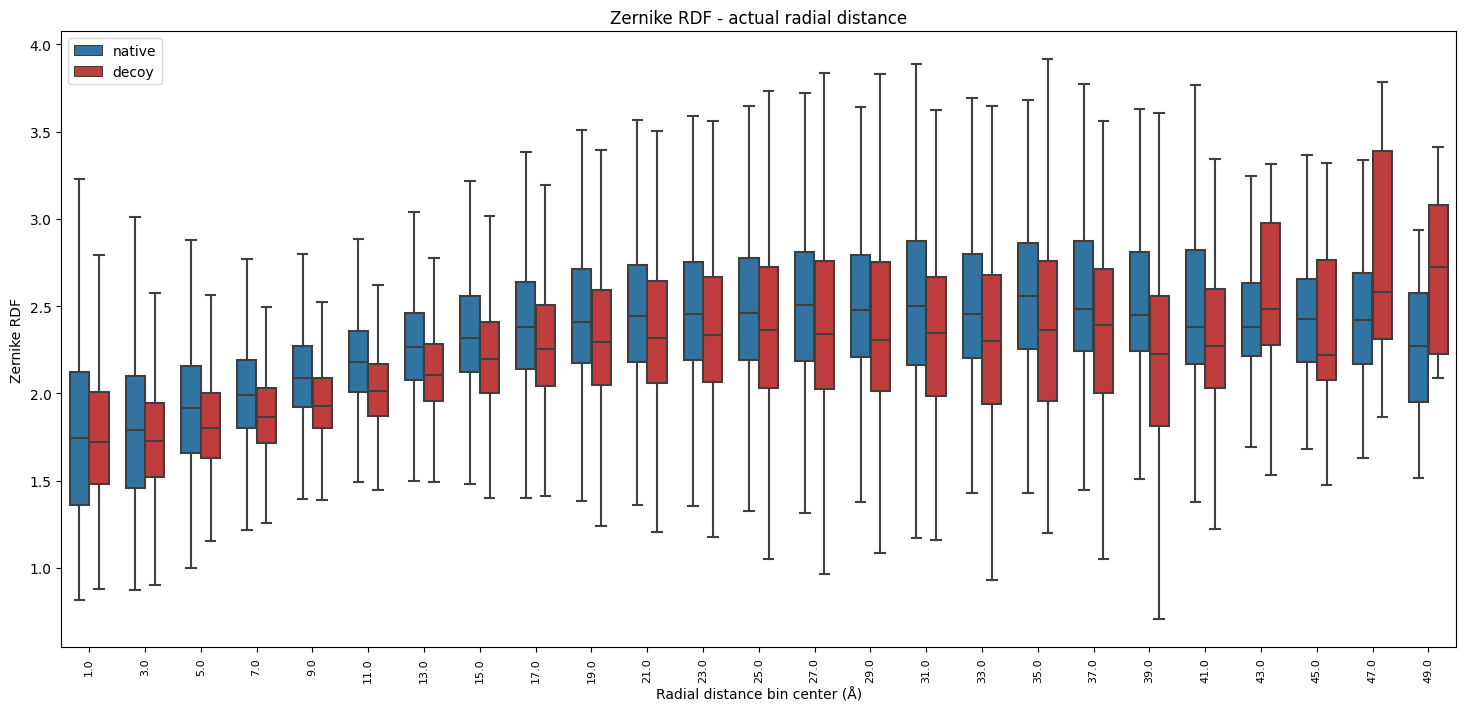

In [6]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=zernike_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    showfliers=False,
    width=0.7,
    ax=ax,
)
ax.set_title('Zernike RDF - actual radial distance')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Zernike RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
fig.savefig('plots/zernike_rdf_radial.pdf', bbox_inches='tight')
plt.show()

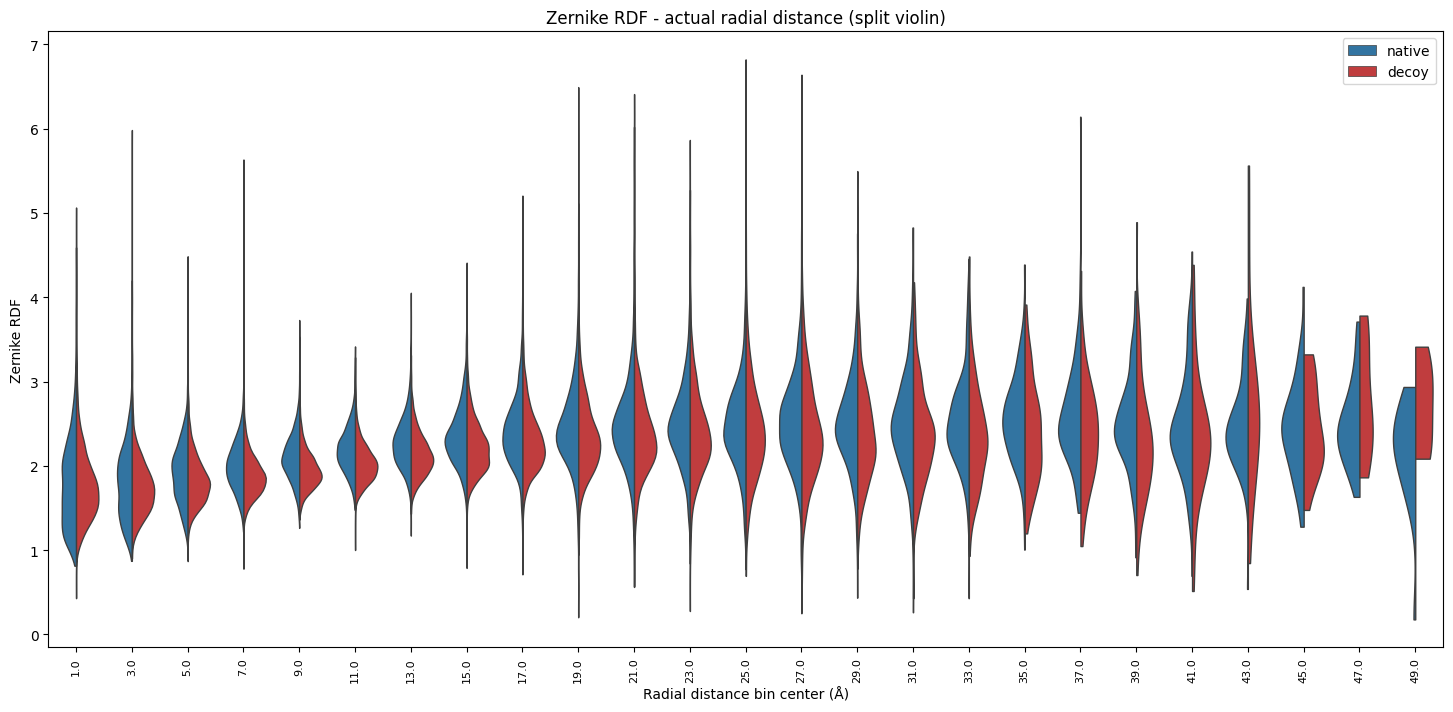

In [14]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.violinplot(
    data=zernike_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    split=True,
    palette=palette,
    inner=None,
    cut=0,
    width=0.8,
    linewidth=1,
    ax=ax,
)
ax.set_title('Zernike RDF - actual radial distance (split violin)')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Zernike RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
fig.savefig('plots/zernike_rdf_radial_violin.pdf', bbox_inches='tight')
plt.show()

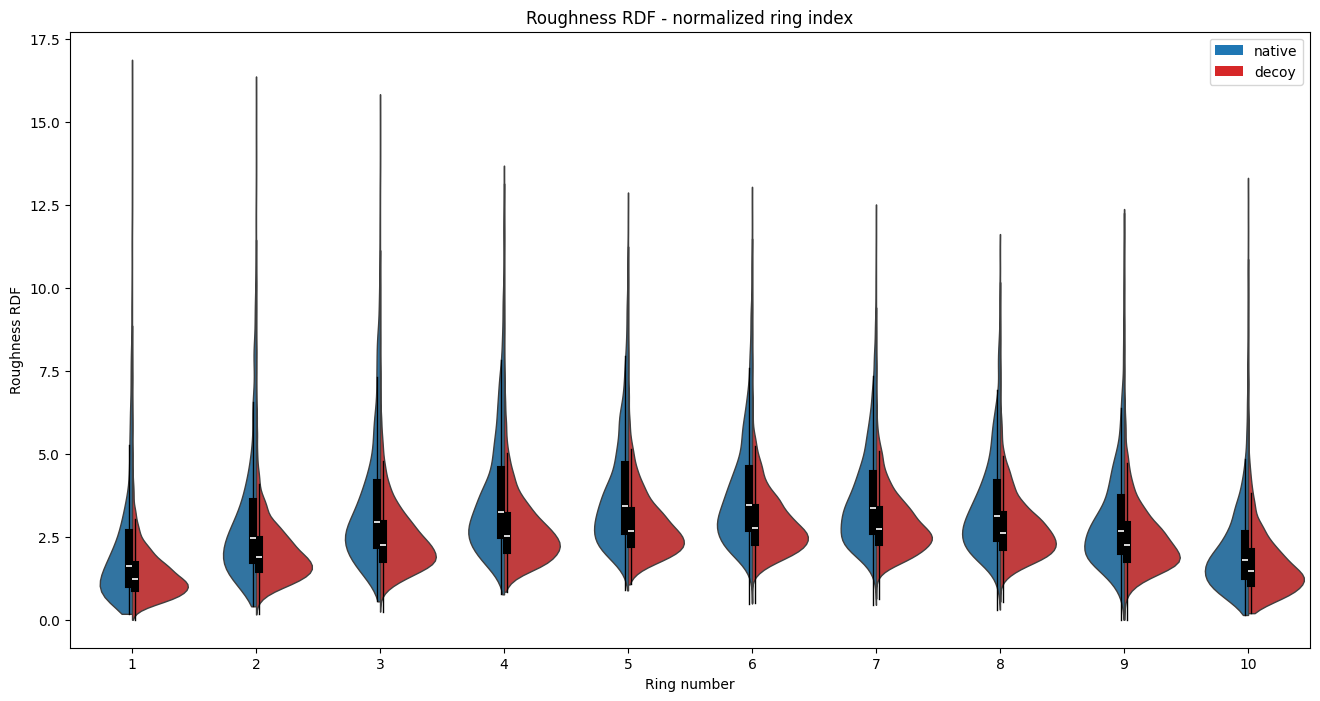

In [7]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(
    data=roughness_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    split=True,
    inner=None,
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
sns.boxplot(
    data=roughness_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    width=0.10,
    whis=1.5,
    showfliers=False,
    showcaps=False,
    boxprops={'facecolor': 'black', 'edgecolor': 'black', 'zorder': 3},
    whiskerprops={'color': 'black', 'linewidth': 1.0},
    capprops={'color': 'black', 'linewidth': 0.0},
    medianprops={'color': 'white', 'linewidth': 1.2, 'zorder': 5},
    ax=ax,
)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.legend(handles=[
    mpatches.Patch(facecolor=palette['native'], label='native'),
    mpatches.Patch(facecolor=palette['decoy'], label='decoy'),
], title='')
ax.set_title('Roughness RDF - normalized ring index')
ax.set_xlabel('Ring number')
ax.set_ylabel('Roughness RDF')
fig.savefig('plots/roughness_rdf_normalized.pdf', bbox_inches='tight')
plt.show()

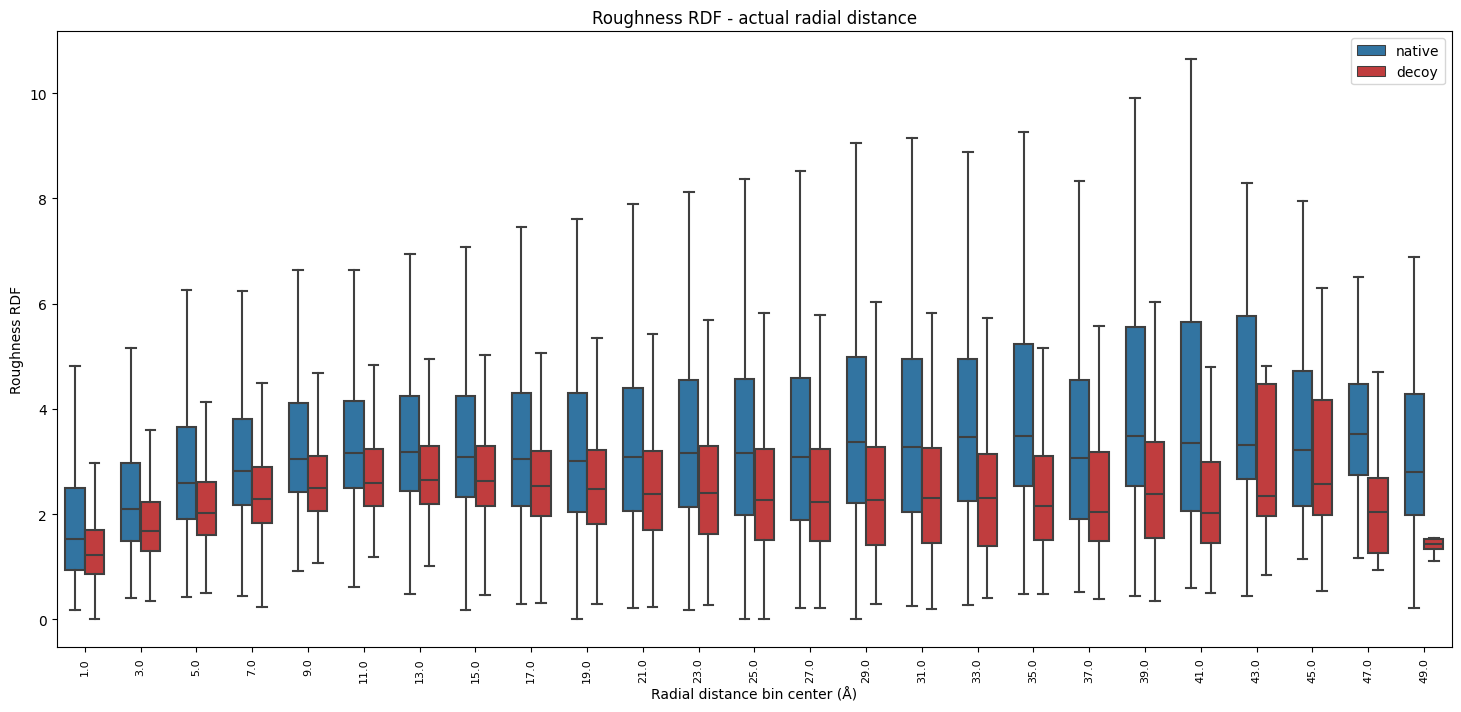

In [8]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=roughness_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    showfliers=False,
    width=0.7,
    ax=ax,
)
ax.set_title('Roughness RDF - actual radial distance')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Roughness RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
fig.savefig('plots/roughness_rdf_radial.pdf', bbox_inches='tight')
plt.show()

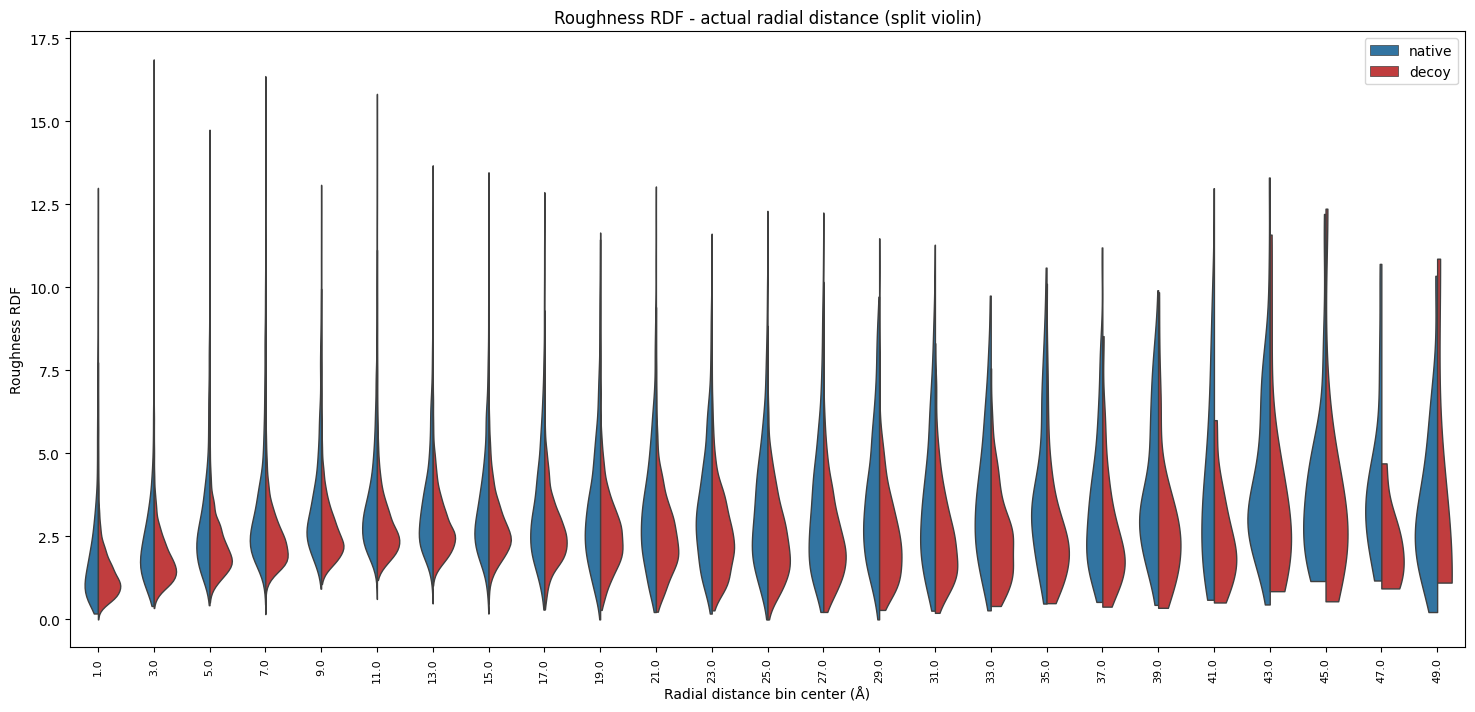

In [15]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.violinplot(
    data=roughness_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    split=True,
    palette=palette,
    inner=None,
    cut=0,
    width=0.8,
    linewidth=1,
    ax=ax,
)
ax.set_title('Roughness RDF - actual radial distance (split violin)')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Roughness RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
fig.savefig('plots/roughness_rdf_radial_violin.pdf', bbox_inches='tight')
plt.show()

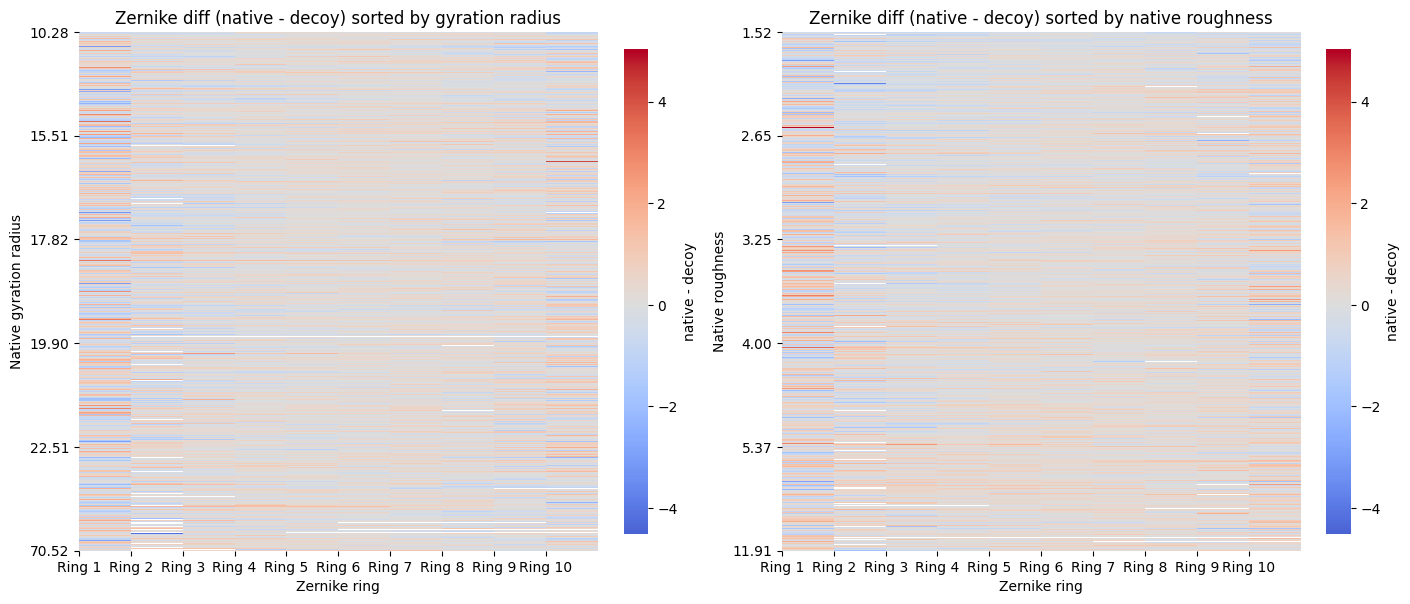

In [9]:
# Heatmaps of per-complex Zernike difference from tot_df (native - decoy)
# Each complex appears twice in tot_df: once as native and once as decoy.

zernike_diff_df = (
    tot_df.pivot_table(
        index='complex_name',
        columns='dataset_label',
        values=zernike,
        aggfunc='mean',
    )
)

if isinstance(zernike_diff_df.columns, pd.MultiIndex):
    zernike_diff_df.columns = zernike_diff_df.columns.set_names(['ring', 'dataset'])

native_z = zernike_diff_df.xs('native', level='dataset', axis=1)
decoy_z = zernike_diff_df.xs('decoy', level='dataset', axis=1)
diff_df = native_z.subtract(decoy_z)

native_meta = (
    tot_df.loc[tot_df['dataset_label'] == 'native']
    .groupby('complex_name')[['gyration_radius', 'roughness']]
    .mean()
)

gyr_sorted = native_meta['gyration_radius'].reindex(diff_df.index).sort_values(kind='mergesort')
rough_sorted = native_meta['roughness'].reindex(diff_df.index).sort_values(kind='mergesort')

gyr_sort_idx = gyr_sorted.index
rough_sort_idx = rough_sorted.index

def set_metric_ticks(ax, metric_values, n_ticks=6):
    if len(metric_values) == 0:
        ax.set_yticks([])
        return

    tick_positions = np.linspace(0, len(metric_values) - 1, num=min(n_ticks, len(metric_values)), dtype=int)
    tick_positions = np.unique(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels([f'{metric_values.iloc[pos]:.2f}' for pos in tick_positions])

cmap_name = 'coolwarm'

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

heatmap_kws = {'cmap': cmap_name, 'center': 0, 'cbar_kws': {'shrink': 0.7, 'label': 'native - decoy'}, 'yticklabels': False}

sns.heatmap(
    diff_df.reindex(gyr_sort_idx),
    ax=axes[0],
    **heatmap_kws,
)
sns.heatmap(
    diff_df.reindex(rough_sort_idx),
    ax=axes[1],
    **heatmap_kws,
)

ring_labels = [f'Ring {i}' for i in range(1, len(zernike) + 1)]
for ax in axes:
    ax.set_xticks(range(len(zernike)))
    ax.set_xticklabels(ring_labels, rotation=0)
    ax.set_xlabel('Zernike ring')
    ax.set_ylabel('')
    ax.set_box_aspect(1)

set_metric_ticks(axes[0], gyr_sorted)
set_metric_ticks(axes[1], rough_sorted)

axes[0].set_title('Zernike diff (native - decoy) sorted by gyration radius')
axes[1].set_title('Zernike diff (native - decoy) sorted by native roughness')
axes[0].set_ylabel('Native gyration radius')
axes[1].set_ylabel('Native roughness')

fig.savefig('plots/zernike_diff_heatmaps_tot_df.pdf', bbox_inches='tight')

/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


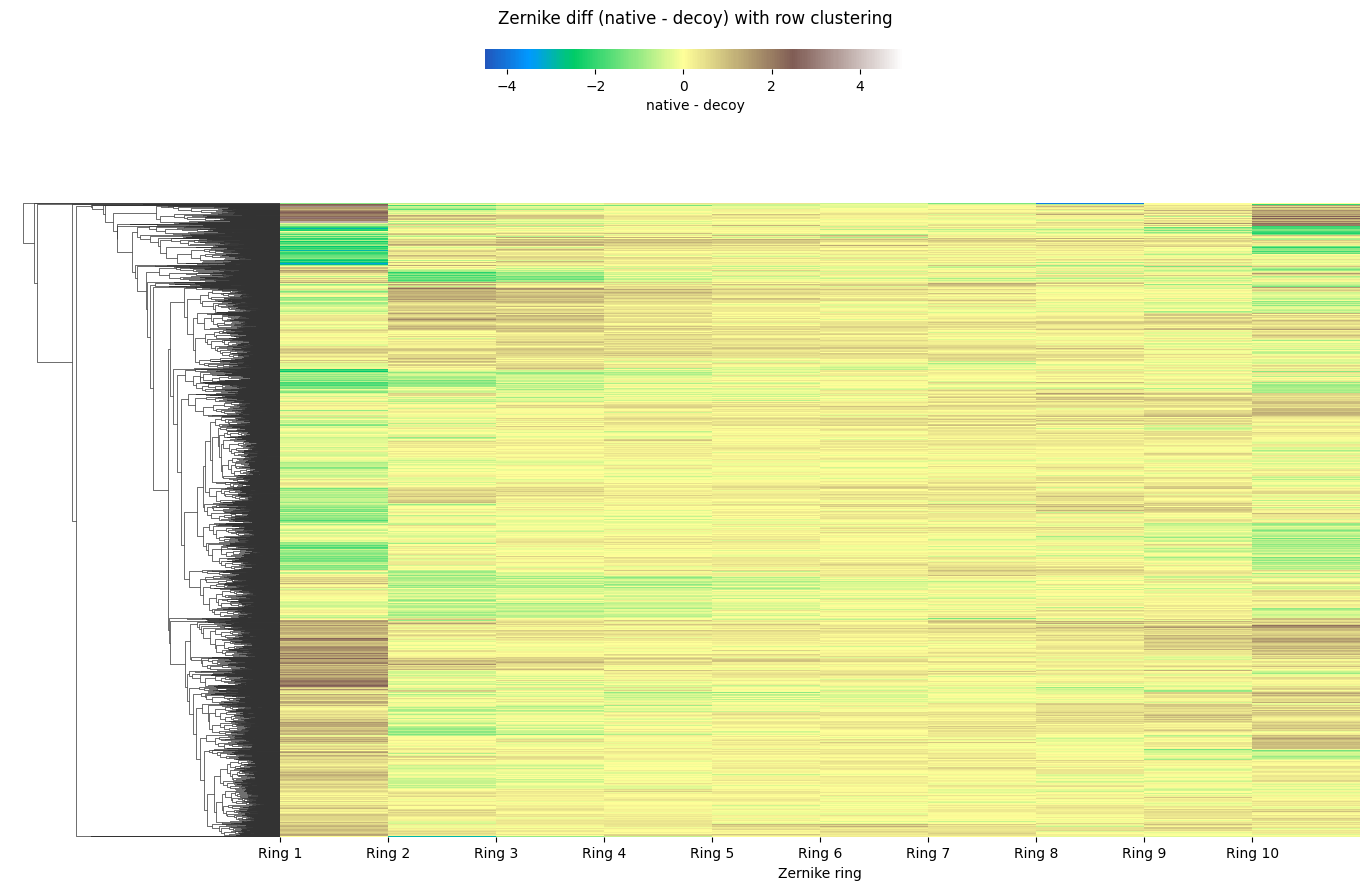

In [10]:
# Heatmap with hierarchical clustering on rows only
# Columns stay in the same ring order, while Seaborn reorders complexes automatically.

cluster_df = diff_df.fillna(0)
cmap_name_cluster = 'terrain'

g_cluster = sns.clustermap(
    cluster_df,
    row_cluster=True,
    col_cluster=False,
    cmap=cmap_name_cluster,
    center=0,
    figsize=(14, 10),
    yticklabels=False,
    cbar_kws={'label': 'native - decoy', 'orientation': 'horizontal'},
    cbar_pos=(0.35, 0.96, 0.3, 0.02),
)

g_cluster.ax_heatmap.set_xticks(range(len(zernike)))
g_cluster.ax_heatmap.set_xticklabels(ring_labels, rotation=0)
g_cluster.ax_heatmap.set_xlabel('Zernike ring')
g_cluster.ax_heatmap.set_ylabel('')
g_cluster.fig.suptitle('Zernike diff (native - decoy) with row clustering', y=1.02)
g_cluster.fig.savefig('plots/zernike_diff_heatmap_clustered.pdf', bbox_inches='tight')

In [11]:
# PCA scatter plots for per-complex difference vectors across the 10 rings
# One subplot for Zernike, one for Physical, and one for Roughness.


def pca_2d_scores(df):
    matrix = df.to_numpy(dtype=float)
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)
    matrix = matrix - matrix.mean(axis=0, keepdims=True)

    u, s, vt = np.linalg.svd(matrix, full_matrices=False)
    scores = u[:, :2] * s[:2]
    return scores


pca_inputs = [
    ('Zernike diff', diff_df.fillna(0), 'tab:blue'),
    ('Physical diff', physical_diff.fillna(0), 'tab:green'),
    ('Roughness diff', roughness_diff.fillna(0), 'tab:orange'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for ax, (title, diff_matrix, color) in zip(axes, pca_inputs):
    scores = pca_2d_scores(diff_matrix)
    ax.scatter(scores[:, 0], scores[:, 1], s=14, alpha=0.65, color=color, edgecolors='none')
    ax.axhline(0, color='0.75', linewidth=0.8)
    ax.axvline(0, color='0.75', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_aspect('equal', adjustable='datalim')

fig.savefig('plots/pca_diff_scatter_triplet.pdf', bbox_inches='tight')
plt.show()

NameError: name 'physical_diff' is not defined

/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtua


Zernike RDF ring -> PC transform
                        PC1     PC2
zernike_ring1_mean  -0.0644 -0.6679
zernike_ring2_mean  -0.0632 -0.4945
zernike_ring3_mean  -0.0723 -0.3495
zernike_ring4_mean  -0.0709 -0.2470
zernike_ring5_mean  -0.0782 -0.1887
zernike_ring6_mean  -0.0967 -0.1571
zernike_ring7_mean  -0.1371 -0.1201
zernike_ring8_mean  -0.2402 -0.0796
zernike_ring9_mean  -0.4846  0.0239
zernike_ring10_mean -0.8092  0.2113

Physical RDF ring -> PC transform
                         PC1     PC2
physical_ring1_mean  -0.0014  0.0354
physical_ring2_mean  -0.0013  0.0330
physical_ring3_mean  -0.0009  0.0249
physical_ring4_mean  -0.0001  0.0156
physical_ring5_mean   0.0002  0.0017
physical_ring6_mean   0.0020 -0.0098
physical_ring7_mean   0.0027 -0.0295
physical_ring8_mean   0.0123 -0.1414
physical_ring9_mean  -0.0837 -0.9845
physical_ring10_mean -0.9964  0.0808


/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtua


Roughness RDF ring -> PC transform
                     PC1     PC2
roughness_ring1   0.2747 -0.4348
roughness_ring2   0.3484 -0.4338
roughness_ring3   0.3881 -0.3031
roughness_ring4   0.3895 -0.1099
roughness_ring5   0.3644  0.0686
roughness_ring6   0.3303  0.1920
roughness_ring7   0.3000  0.2892
roughness_ring8   0.2778  0.3664
roughness_ring9   0.2509  0.4039
roughness_ring10  0.1699  0.3103


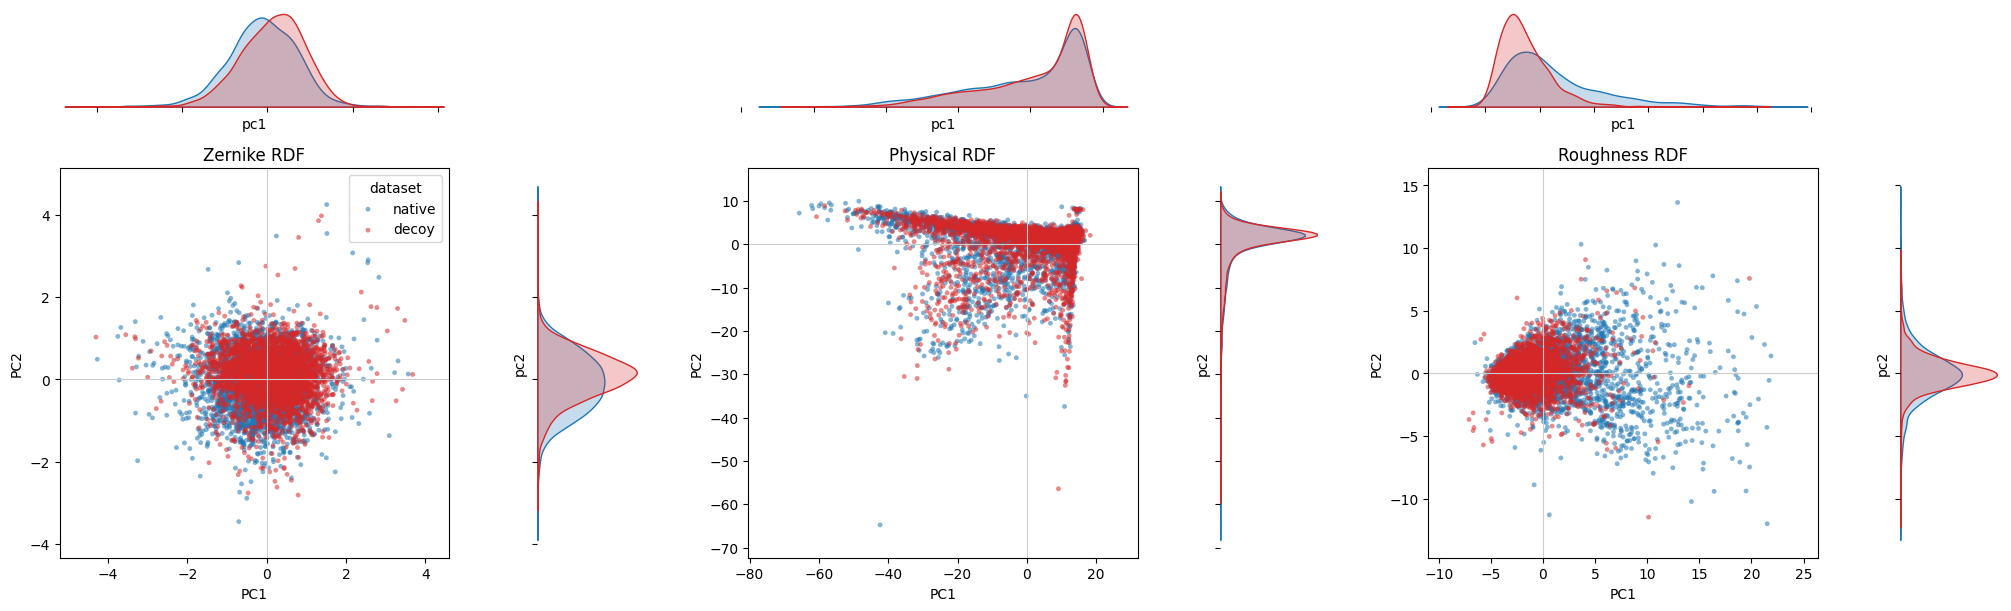

In [ ]:
# PCA jointplots for the raw RDF vectors of native and decoy complexes
# Each panel shows PC1 vs PC2 plus marginal distributions for native and decoy.


def pca_2d_scores(df):
    matrix = df.to_numpy(dtype=float)
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)
    matrix = matrix - matrix.mean(axis=0, keepdims=True)

    u, s, vt = np.linalg.svd(matrix, full_matrices=False)
    scores = u[:, :2] * s[:2]
    return scores, vt[:2]


def build_dataset_matrix(df, value_cols):
    return (
        df.groupby(['complex_name', 'dataset_label'], as_index=False)[value_cols]
        .mean()
        .copy()
    )


def make_pca_frame(df, value_cols):
    metric_df = build_dataset_matrix(df, value_cols)
    scores, components = pca_2d_scores(metric_df[value_cols])
    pca_df = metric_df[['complex_name', 'dataset_label']].copy()
    pca_df['pc1'] = scores[:, 0]
    pca_df['pc2'] = scores[:, 1]
    return pca_df, components


def print_pca_transform(title, value_cols, components):
    transform_df = pd.DataFrame(
        components.T,
        index=value_cols,
        columns=['PC1', 'PC2'],
    )
    print(f'\n{title} ring -> PC transform')
    print(transform_df.to_string(float_format=lambda x: f'{x: .4f}'))


raw_pca_frames = [
    ('Zernike RDF', *make_pca_frame(tot_df, zernike)),
    ('Physical RDF', *make_pca_frame(tot_df, physical)),
    ('Roughness RDF', *make_pca_frame(tot_df, roughness)),
]

fig = plt.figure(figsize=(20, 6), constrained_layout=True)
subfigs = fig.subfigures(1, 3, wspace=0.06)

for subfig, (title, pca_df, components) in zip(subfigs, raw_pca_frames):
    gs = subfig.add_gridspec(2, 2, height_ratios=[1, 4], width_ratios=[4, 1], hspace=0.05, wspace=0.05)
    ax_joint = subfig.add_subplot(gs[1, 0])
    ax_marg_x = subfig.add_subplot(gs[0, 0], sharex=ax_joint)
    ax_marg_y = subfig.add_subplot(gs[1, 1], sharey=ax_joint)

    for dataset_label, dataset_color in palette.items():
        subset = pca_df[pca_df['dataset_label'] == dataset_label]
        ax_joint.scatter(
            subset['pc1'],
            subset['pc2'],
            s=12,
            alpha=0.55,
            color=dataset_color,
            label=dataset_label,
            edgecolors='none',
        )
        sns.kdeplot(
            data=subset,
            x='pc1',
            ax=ax_marg_x,
            color=dataset_color,
            fill=True,
            alpha=0.25,
            linewidth=1,
        )
        sns.kdeplot(
            data=subset,
            y='pc2',
            ax=ax_marg_y,
            color=dataset_color,
            fill=True,
            alpha=0.25,
            linewidth=1,
        )

    print_pca_transform(title, [col for col in (zernike if title == 'Zernike RDF' else physical if title == 'Physical RDF' else roughness)], components)

    ax_joint.axhline(0, color='0.8', linewidth=0.8)
    ax_joint.axvline(0, color='0.8', linewidth=0.8)
    ax_joint.set_title(title)
    ax_joint.set_xlabel('PC1')
    ax_joint.set_ylabel('PC2')
    ax_joint.set_box_aspect(1)

    ax_marg_x.set_ylabel('')
    ax_marg_x.tick_params(axis='x', labelbottom=False)
    ax_marg_x.tick_params(axis='y', left=False, labelleft=False)
    sns.despine(ax=ax_marg_x, left=True, bottom=True)

    ax_marg_y.set_xlabel('')
    ax_marg_y.tick_params(axis='y', labelleft=False)
    ax_marg_y.tick_params(axis='x', bottom=False, labelbottom=False)
    sns.despine(ax=ax_marg_y, left=True, bottom=True)

    if title == 'Zernike RDF':
        ax_joint.legend(title='dataset', loc='best')
    else:
        leg = ax_joint.get_legend()
        if leg is not None:
            leg.remove()

fig.savefig('plots/pca_raw_jointplots_triplet.pdf', bbox_inches='tight')
plt.show()

/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


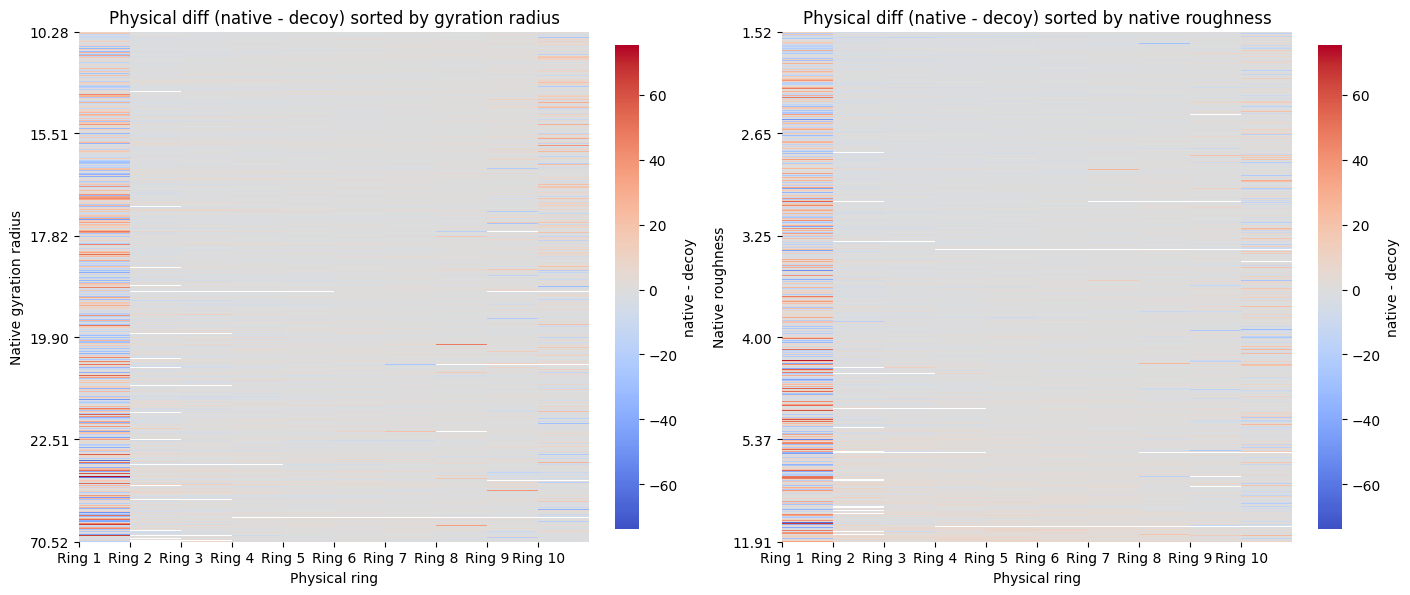

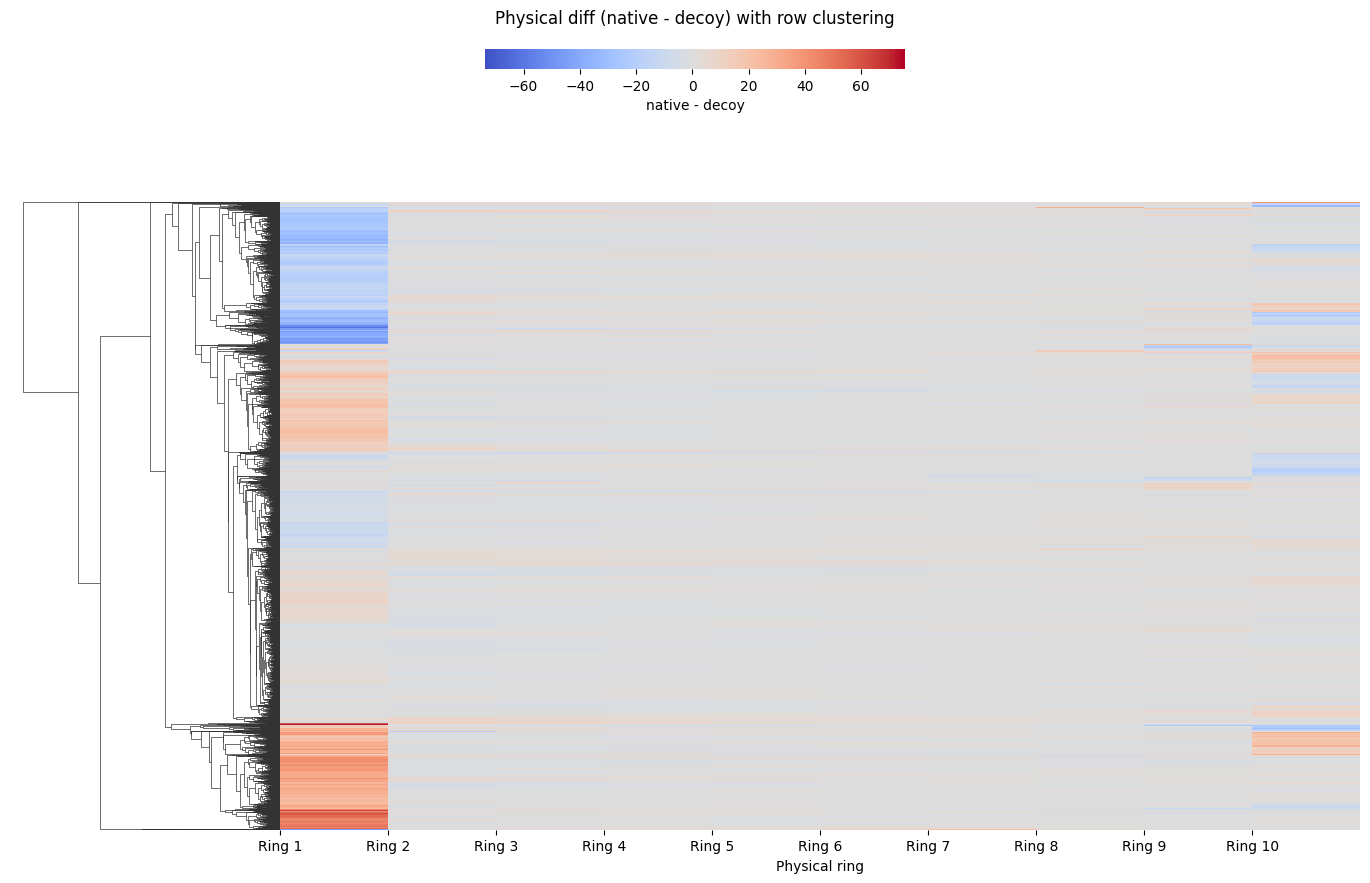

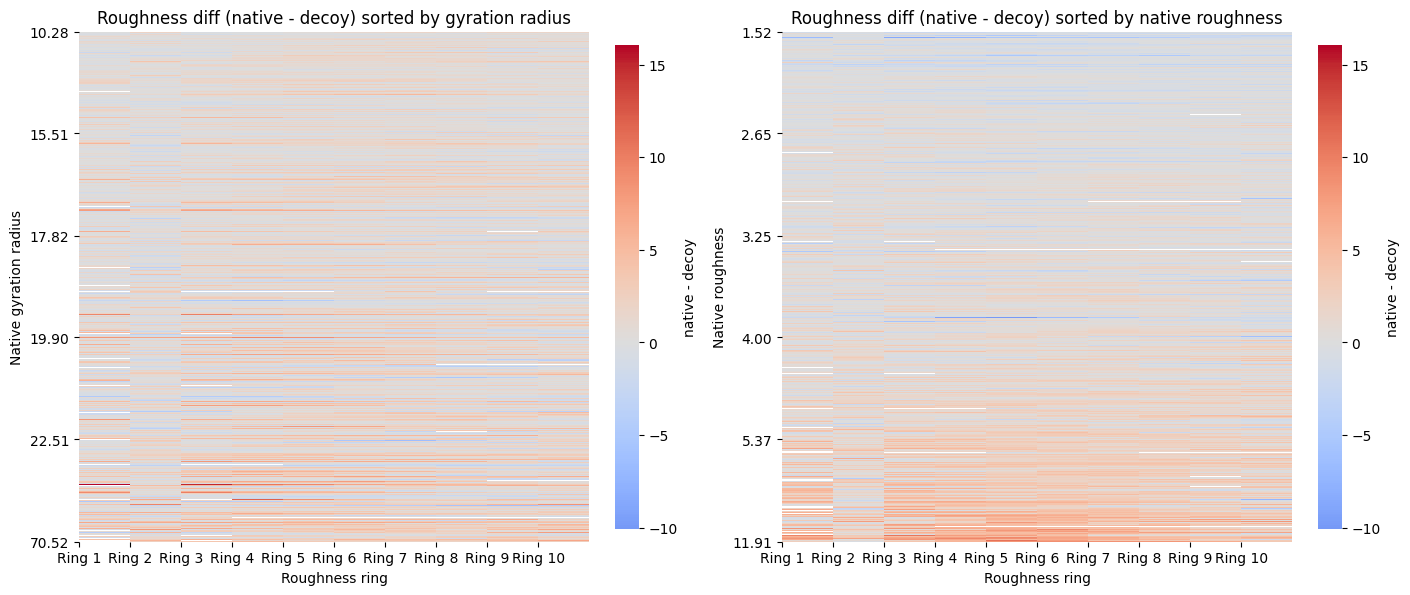

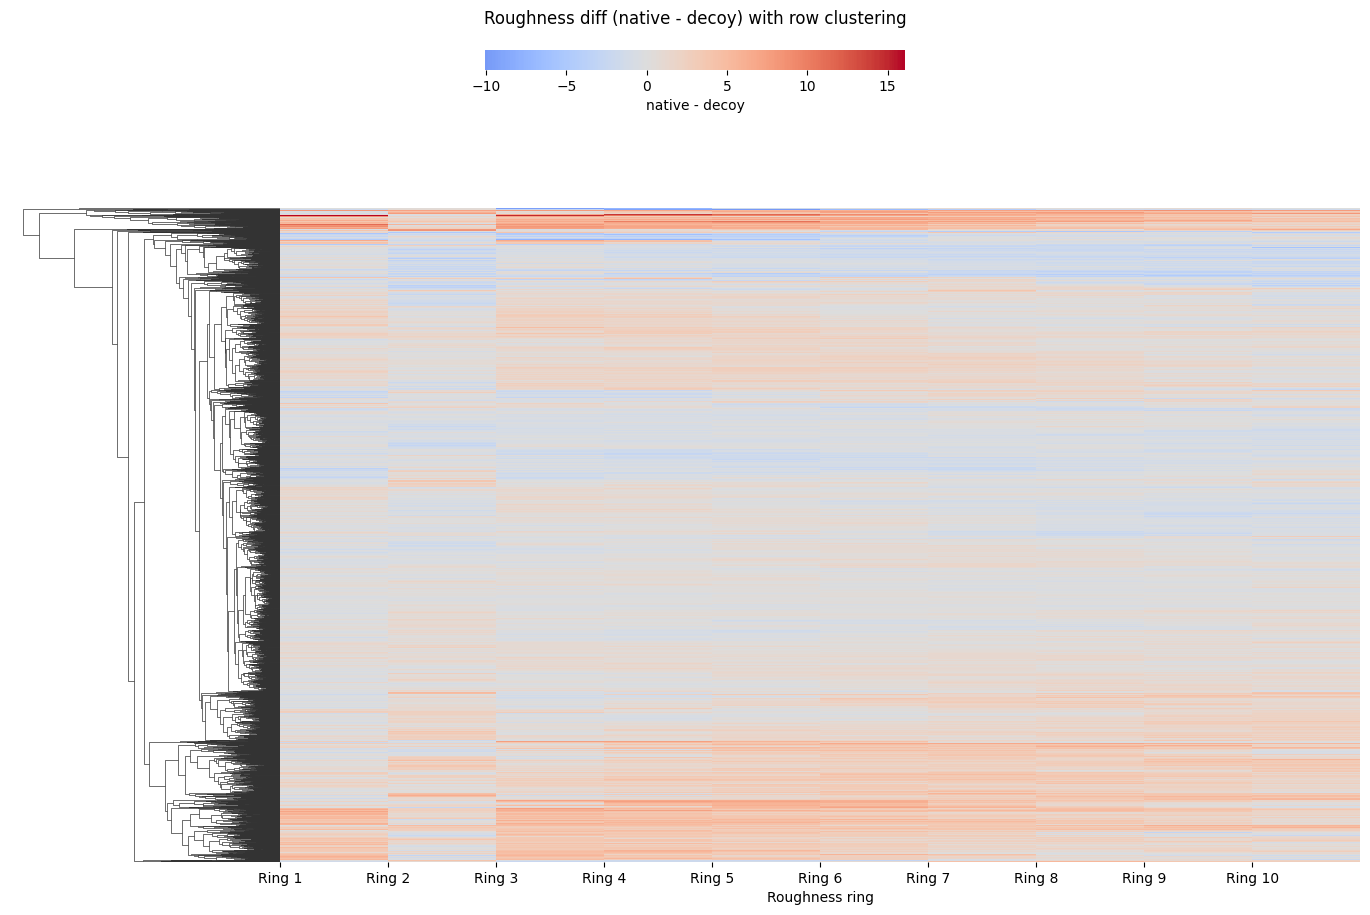

In [ ]:
# --- Physical RDF heatmaps ---

physical_cols = physical
physical_diff_df = (
    tot_df.pivot_table(
        index='complex_name',
        columns='dataset_label',
        values=physical_cols,
        aggfunc='mean',
    )
)

if isinstance(physical_diff_df.columns, pd.MultiIndex):
    physical_diff_df.columns = physical_diff_df.columns.set_names(['ring', 'dataset'])

physical_native = physical_diff_df.xs('native', level='dataset', axis=1)
physical_decoy = physical_diff_df.xs('decoy', level='dataset', axis=1)
physical_diff = physical_native.subtract(physical_decoy)

physical_native_meta = (
    tot_df.loc[tot_df['dataset_label'] == 'native']
    .groupby('complex_name')[['gyration_radius', 'roughness']]
    .mean()
)

physical_gyr_sorted = physical_native_meta['gyration_radius'].reindex(physical_diff.index).sort_values(kind='mergesort')
physical_rough_sorted = physical_native_meta['roughness'].reindex(physical_diff.index).sort_values(kind='mergesort')

physical_gyr_sort_idx = physical_gyr_sorted.index
physical_rough_sort_idx = physical_rough_sorted.index

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

heatmap_kws = {'cmap': cmap_name, 'center': 0, 'cbar_kws': {'shrink': 0.7, 'label': 'native - decoy'}, 'yticklabels': False}

sns.heatmap(
    physical_diff.reindex(physical_gyr_sort_idx),
    ax=axes[0],
    **heatmap_kws,
)
sns.heatmap(
    physical_diff.reindex(physical_rough_sort_idx),
    ax=axes[1],
    **heatmap_kws,
)

physical_ring_labels = [f'Ring {i}' for i in range(1, len(physical_cols) + 1)]
for ax in axes:
    ax.set_xticks(range(len(physical_cols)))
    ax.set_xticklabels(physical_ring_labels, rotation=0)
    ax.set_xlabel('Physical ring')
    ax.set_ylabel('')
    ax.set_box_aspect(1)

set_metric_ticks(axes[0], physical_gyr_sorted)
set_metric_ticks(axes[1], physical_rough_sorted)

axes[0].set_title('Physical diff (native - decoy) sorted by gyration radius')
axes[1].set_title('Physical diff (native - decoy) sorted by native roughness')
axes[0].set_ylabel('Native gyration radius')
axes[1].set_ylabel('Native roughness')

fig.savefig('plots/physical_diff_heatmaps_tot_df.pdf', bbox_inches='tight')

# Physical RDF with hierarchical clustering on rows only
physical_cluster_df = physical_diff.fillna(0)
physical_cmap_name_cluster = cmap_name

physical_g_cluster = sns.clustermap(
    physical_cluster_df,
    row_cluster=True,
    col_cluster=False,
    cmap=physical_cmap_name_cluster,
    center=0,
    figsize=(14, 10),
    yticklabels=False,
    cbar_kws={'label': 'native - decoy', 'orientation': 'horizontal'},
    cbar_pos=(0.35, 0.96, 0.3, 0.02),
)

physical_g_cluster.ax_heatmap.set_xticks(range(len(physical_cols)))
physical_g_cluster.ax_heatmap.set_xticklabels(physical_ring_labels, rotation=0)
physical_g_cluster.ax_heatmap.set_xlabel('Physical ring')
physical_g_cluster.ax_heatmap.set_ylabel('')
physical_g_cluster.fig.suptitle('Physical diff (native - decoy) with row clustering', y=1.02)
physical_g_cluster.fig.savefig('plots/physical_diff_heatmap_clustered.pdf', bbox_inches='tight')

# --- Roughness RDF heatmaps ---

roughness_cols = roughness
roughness_diff_df = (
    tot_df.pivot_table(
        index='complex_name',
        columns='dataset_label',
        values=roughness_cols,
        aggfunc='mean',
    )
)

if isinstance(roughness_diff_df.columns, pd.MultiIndex):
    roughness_diff_df.columns = roughness_diff_df.columns.set_names(['ring', 'dataset'])

roughness_native = roughness_diff_df.xs('native', level='dataset', axis=1)
roughness_decoy = roughness_diff_df.xs('decoy', level='dataset', axis=1)
roughness_diff = roughness_native.subtract(roughness_decoy)

roughness_native_meta = (
    tot_df.loc[tot_df['dataset_label'] == 'native']
    .groupby('complex_name')[['gyration_radius', 'roughness']]
    .mean()
)

roughness_gyr_sorted = roughness_native_meta['gyration_radius'].reindex(roughness_diff.index).sort_values(kind='mergesort')
roughness_rough_sorted = roughness_native_meta['roughness'].reindex(roughness_diff.index).sort_values(kind='mergesort')

roughness_gyr_sort_idx = roughness_gyr_sorted.index
roughness_rough_sort_idx = roughness_rough_sorted.index

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

sns.heatmap(
    roughness_diff.reindex(roughness_gyr_sort_idx),
    ax=axes[0],
    **heatmap_kws,
)
sns.heatmap(
    roughness_diff.reindex(roughness_rough_sort_idx),
    ax=axes[1],
    **heatmap_kws,
)

roughness_ring_labels = [f'Ring {i}' for i in range(1, len(roughness_cols) + 1)]
for ax in axes:
    ax.set_xticks(range(len(roughness_cols)))
    ax.set_xticklabels(roughness_ring_labels, rotation=0)
    ax.set_xlabel('Roughness ring')
    ax.set_ylabel('')
    ax.set_box_aspect(1)

set_metric_ticks(axes[0], roughness_gyr_sorted)
set_metric_ticks(axes[1], roughness_rough_sorted)

axes[0].set_title('Roughness diff (native - decoy) sorted by gyration radius')
axes[1].set_title('Roughness diff (native - decoy) sorted by native roughness')
axes[0].set_ylabel('Native gyration radius')
axes[1].set_ylabel('Native roughness')

fig.savefig('plots/roughness_diff_heatmaps_tot_df.pdf', bbox_inches='tight')

# Roughness RDF with hierarchical clustering on rows only
roughness_cluster_df = roughness_diff.fillna(0)
roughness_cmap_name_cluster = cmap_name

roughness_g_cluster = sns.clustermap(
    roughness_cluster_df,
    row_cluster=True,
    col_cluster=False,
    cmap=roughness_cmap_name_cluster,
    center=0,
    figsize=(14, 10),
    yticklabels=False,
    cbar_kws={'label': 'native - decoy', 'orientation': 'horizontal'},
    cbar_pos=(0.35, 0.96, 0.3, 0.02),
)

roughness_g_cluster.ax_heatmap.set_xticks(range(len(roughness_cols)))
roughness_g_cluster.ax_heatmap.set_xticklabels(roughness_ring_labels, rotation=0)
roughness_g_cluster.ax_heatmap.set_xlabel('Roughness ring')
roughness_g_cluster.ax_heatmap.set_ylabel('')
roughness_g_cluster.fig.suptitle('Roughness diff (native - decoy) with row clustering', y=1.02)
roughness_g_cluster.fig.savefig('plots/roughness_diff_heatmap_clustered.pdf', bbox_inches='tight')